<a href="https://colab.research.google.com/github/harinisridhar2608-Sri/Upskill-DataScience-Project/blob/main/TrafficForecasting_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files
uploaded = files.upload()


Saving datasets_8494_11879_test_BdBKkAj.csv to datasets_8494_11879_test_BdBKkAj.csv
Saving train_aWnotuB.csv to train_aWnotuB.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [7]:
train_df = pd.read_csv("train_aWnotuB.csv")
test_df = pd.read_csv("datasets_8494_11879_test_BdBKkAj.csv")

print(train_df.head())
print(train_df.info())


              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [8]:
# select first numeric column automatically
train_series = train_df.select_dtypes(include=['number']).iloc[:,0]
test_series = test_df.select_dtypes(include=['number']).iloc[:,0]


In [ ]:
arima_model = ARIMA(train_series, order=(2,1,2))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test_series))

arima_mae = mean_absolute_error(test_series, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test_series, arima_pred))

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)


ARIMA MAE: 1.5
ARIMA RMSE: 1.8708286933869707


In [9]:
arima_model = ARIMA(train_series, order=(2,1,2))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test_series))

arima_mae = mean_absolute_error(test_series, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test_series, arima_pred))

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)


ARIMA MAE: 1.5
ARIMA RMSE: 1.8708286933869707


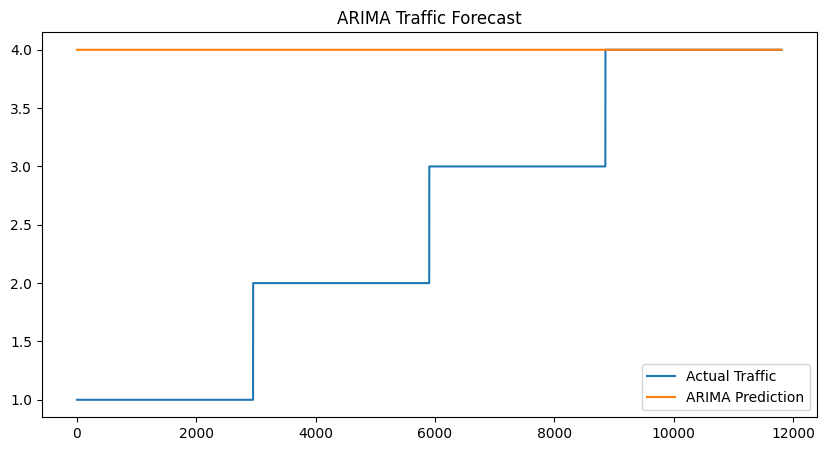

In [10]:
plt.figure(figsize=(10,5))
plt.plot(test_series.values, label="Actual Traffic")
plt.plot(arima_pred.values, label="ARIMA Prediction")
plt.legend()
plt.title("ARIMA Traffic Forecast")
plt.show()


In [11]:
full_data = pd.concat([train_series, test_series])

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(full_data.values.reshape(-1,1))

def create_dataset(data, look_back=10):
    X, y = [], []
    for i in range(len(data)-look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)

split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0117
Epoch 2/5
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 2.8797e-05
Epoch 3/5
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 3.4014e-05
Epoch 4/5
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 1.6908e-05
Epoch 5/5
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 3.8277e-05


In [13]:
lstm_pred = model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test)

lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
LSTM MAE: 0.002138871644861071
LSTM RMSE: 0.051231086084277774


In [15]:
lstm_pred = model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test)

lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM MAE: 0.002138871644861071
LSTM RMSE: 0.051231086084277774


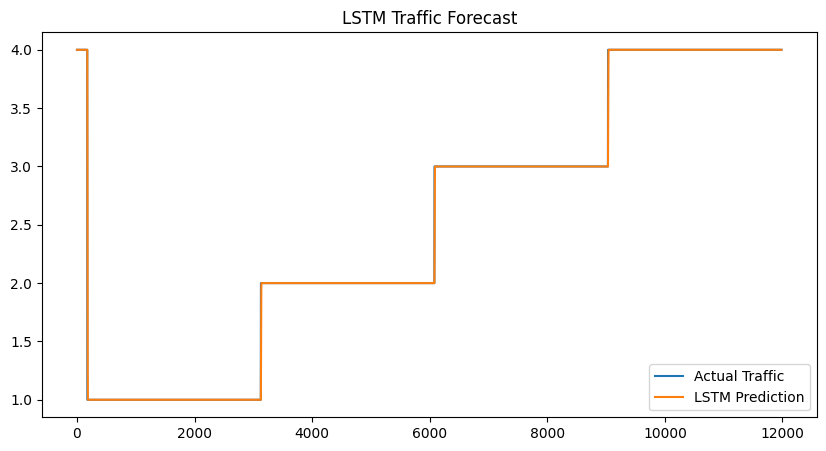

In [14]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual Traffic")
plt.plot(lstm_pred, label="LSTM Prediction")
plt.legend()
plt.title("LSTM Traffic Forecast")
plt.show()
